# CME Futures: Strategy Analysis

The four preceding notebooks each produced a registered, complete population of validation
backtests: the equal-weight signal baseline over every model configuration and checkpoint, the
alternative allocators over the signal shortlist, the transaction-cost grid, and the position-risk
overlays. This notebook reads those registered results and names one case-study configuration
from them.

A case-study configuration is a model configuration - family, settings, and the training
checkpoint the predictions came from - together with the signal, sizing, and risk rules applied to
it. The configuration with the highest validation Sharpe across the signal, allocation, and
risk-overlay stages is the one selected. Cost-sensitivity backtests vary the friction assumption
on a configuration already chosen, so they describe it rather than compete with it and are not in
the pool.

Both return horizons are selected from together. The horizon is part of the configuration, so it
is read off the row that wins rather than fixed before looking.

The holdout period is a later date range that no notebook up to this point has touched. It is
evaluated on the selected configuration alone, one time, and it may disagree with the validation
result. That disagreement is an outcome to report, not a reason to select again.

Prerequisites: `13_backtest`, `14_portfolio_management`, `15_risk_management`, and `16_costs`.

In [1]:
"""Select and describe one CME futures case-study configuration."""

import plotly.express as px
import polars as pl

from case_studies.cme_futures.research_workflow import (
    ALL_LABELS,
    final_selection_candidate_set,
    final_validation_candidate_set,
    final_validation_results,
    open_study,
    product_universe_table,
    selection_catalog,
)
from case_studies.research import OfficialPopulation, Result
from case_studies.utils.cohort_metrics import compute_and_register
from case_studies.utils.paired_metrics import populate_paired_metrics
from case_studies.utils.strategy_analysis import (
    resolve_solvent_carrier,
    select_holdout_self_backtest,
)
from utils.style import COLORS

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE: str | None = None
PREVIEW_LABELS: list[str] = []

## The pool the configuration is selected from

Each per-label pool opens the three stage populations and fails if any member is missing,
incomplete, or produced under a preview identity. Combining the two horizons into one immutable
set records exactly which results were compared, so the selection can be repeated later against
the same members rather than against whatever the registry holds at the time.

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE)
if EXECUTION_TIER == "canonical":
    if PREVIEW_LABELS:
        raise ValueError("canonical execution cannot declare preview reductions")
    labels = ALL_LABELS
elif EXECUTION_TIER == "preview":
    if WORKSPACE is None or not PREVIEW_LABELS:
        raise ValueError("preview execution requires WORKSPACE and PREVIEW_LABELS")
    unknown = sorted(set(PREVIEW_LABELS) - set(ALL_LABELS))
    if unknown:
        raise ValueError(f"preview labels this case study does not declare: {unknown}")
    labels = tuple(PREVIEW_LABELS)
else:
    raise ValueError(f"unsupported execution tier: {EXECUTION_TIER!r}")
universe = product_universe_table()
universe

sector,product,expiry_rule,contract_months
str,str,str,str
"""agriculture""","""ZC""","""business_day_before_15th""","""H,K,N,U,Z"""
"""agriculture""","""ZL""","""business_day_before_15th""","""F,H,K,N,Q,U,V,Z"""
"""agriculture""","""ZM""","""business_day_before_15th""","""F,H,K,N,Q,U,V,Z"""
"""agriculture""","""ZS""","""business_day_before_15th""","""F,H,K,N,Q,U,X"""
"""agriculture""","""ZW""","""business_day_before_15th""","""H,K,N,U,Z"""
…,…,…,…
"""metals""","""SI""","""3rd_last_business_day""","""H,K,N,U,Z"""
"""treasuries""","""ZB""","""last_business_day""","""H,M,U,Z"""
"""treasuries""","""ZF""","""last_business_day""","""H,M,U,Z"""


Only a canonical pool is an immutable set. A preview run publishes no candidate set - one cannot
hold a preview member - so its pool is the rows its own reduced execution produced and the
`candidate_set_hash` column below is null. Everything downstream, the ranking rule included, is
the same either way; what differs is whether the pool can be reopened later by name.

In [4]:
if EXECUTION_TIER == "canonical":
    per_label = {label: final_validation_candidate_set(study, label=label) for label in labels}
    per_label_results = {
        label: tuple(Result.open(study, value) for value in pool_set.members)
        for label, pool_set in per_label.items()
    }
    candidates = final_selection_candidate_set(study)
    pool_results = tuple(Result.open(study, value) for value in candidates.members)
    pool_identity = candidates.hash
    per_label_identity = {label: pool_set.hash for label, pool_set in per_label.items()}
else:
    per_label_results = {
        label: final_validation_results(study, label=label, execution_tier=EXECUTION_TIER)
        for label in labels
    }
    pool_results = tuple(result for results in per_label_results.values() for result in results)
    pool_identity = None
    per_label_identity = dict.fromkeys(labels)
pool = selection_catalog(study, (result.hash for result in pool_results))
pool_size = pl.DataFrame(
    [
        {
            "label": label,
            "candidates": len(results),
            "candidate_set_hash": per_label_identity[label],
        }
        for label, results in per_label_results.items()
    ],
    schema={"label": pl.String, "candidates": pl.Int64, "candidate_set_hash": pl.String},
).sort("label")

## The selection correction, and the paired comparisons

Two registry tables carry the statistics this notebook reports rather than recomputes:
`cohort_metrics` holds the deflated Sharpe for each cohort's leader, and
`backtest_paired_metrics` holds bootstrap comparisons between registered return series.
Both were empty here until 2026-08-31, so an earlier edition of the README quoted deflation
numbers with nothing behind them. The cause was not a bad computation - it was that this
notebook never called for one, while `etfs`, `fx_pairs` and `us_firm_characteristics` all do.

`compute_and_register` refreshes the whole table rather than one row, so it can never report
a stale leader. `populate_paired_metrics` writes one row per comparison kind, including
`val_rank1_self` - the carrier's validation series against its own holdout replay, which is
the paired form of the val-to-holdout question and the only honest way to ask it. Comparing
two point estimates is not that question: the holdout is a shorter window, so the difference
carries sampling error the point estimates do not show.

The carrier is resolved here rather than further down because `populate_paired_metrics` needs
it. Omitting it does not fail - it falls back to ranking the registry on raw Sharpe, which on
this registry names `latent_factors`/`sdf` on `fwd_ret_21d`, while the canonical resolver names
`gbm`/`leaves_31_mse` on `fwd_ret_5d`. The paired rows would then compare a strategy the
chapter does not report, under headings that say they describe the one it does. That is the
same disagreement documented below for the holdout lookup, reaching a different table.

`replace_all=True` makes the call a snapshot rather than an insert. Registration is an upsert
keyed on the pair, so it cannot remove rows a previous selection wrote; without the prune, the
raw-Sharpe pairs would survive alongside the carrier's.

`prediction_hashes` scopes the cohorts to this notebook's own pool. On this registry it changes
nothing - the cohorts are already a strict subset of the pool, because it was rebuilt from empty
and holds no retired generation. That is a property of the registry, not of the call: without the
argument, a superseded generation left in the registry would inflate K and could lead a cohort
outright, and the deflation this notebook publishes would be computed over a variant the pool
excludes. Being right by accident is not the same as being right.

In [5]:
carrier = resolve_solvent_carrier("cme_futures")
cohort_counts = compute_and_register(
    "cme_futures",
    prediction_hashes=pool.get_column("prediction_hash").unique().to_list(),
    verbose=False,
)
paired_rows = populate_paired_metrics(
    "cme_futures", carrier=carrier, replace_all=True, verbose=False
)
print(f"cohort_metrics: {sum(cohort_counts[k] for k in ('family', 'stagelabel', 'label'))} rows")
print(f"backtest_paired_metrics: {sum(1 for r in paired_rows if 'skip' not in r)} pairs")

cohort_metrics: 27 rows
backtest_paired_metrics: 6 pairs


In [6]:
pool_size

label,candidates,candidate_set_hash
str,i64,str
"""fwd_ret_21d""",570,"""9451d58e45e4"""
"""fwd_ret_5d""",570,"""b1e32f51e1d1"""


## What each selection stage contributed

The three stages run in sequence, each on the survivors of the one before. The baseline stage
carries every configuration and checkpoint at equal weight. Allocation runs on the strongest
distinct configurations from that stage, and the risk overlay on the strongest result so far for
each horizon. Later stages therefore hold far fewer candidates than the first, and the spread
within a stage shows how much of the outcome the sizing and risk rules decide once the model is
fixed.

**The medians cannot be read across stages.** Each stage runs on the survivors of the one before,
chosen on the same validation Sharpe the table reports, so the pool shrinks from 496 to 60 to 14
by selecting on the quantity being summarized. On `fwd_ret_21d` the median rises from -0.392 to
0.192 to 1.010 along that shrinking pool, and almost all of that movement is the selection, not
the position sizing methods or the risk rules. What the stages do support is the comparison
within a row: the fourteen risk overlays share one model, one signal and one sizing rule,
and they still span 0.322 to 1.274, which is the range the position rule alone is
responsible for.

In [7]:
stage_summary = (
    pool.group_by("label", "stage")
    .agg(
        pl.len().alias("candidates"),
        pl.col("sharpe").min().alias("min_sharpe"),
        pl.col("sharpe").median().alias("median_sharpe"),
        pl.col("sharpe").max().alias("max_sharpe"),
    )
    .sort("label", "stage")
)

In [8]:
stage_summary

label,stage,candidates,min_sharpe,median_sharpe,max_sharpe
str,str,u32,f64,f64,f64
"""fwd_ret_21d""","""allocation""",60,-0.29416,0.181921,1.138895
"""fwd_ret_21d""","""risk_overlay""",14,0.321874,1.009729,1.27421
"""fwd_ret_21d""","""signal""",496,-1.042364,-0.391721,1.044776
"""fwd_ret_5d""","""allocation""",60,-0.736674,0.406512,0.715717
"""fwd_ret_5d""","""risk_overlay""",14,0.427838,0.736625,1.235576
"""fwd_ret_5d""","""signal""",496,-0.908679,0.063778,0.623463


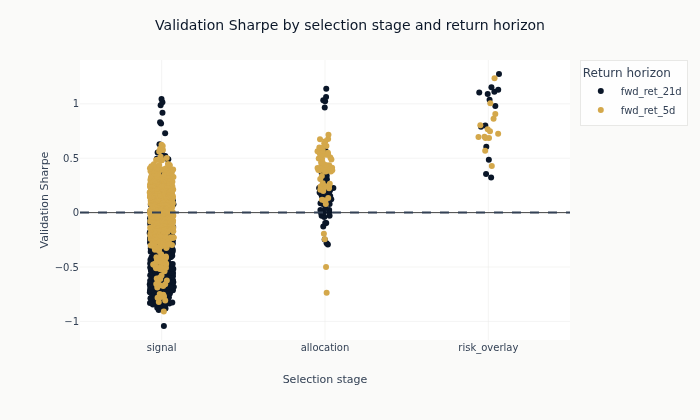

In [9]:
fig = px.strip(
    pool.to_pandas(),
    x="stage",
    y="sharpe",
    color="label",
    stripmode="overlay",
    category_orders={"stage": ["signal", "allocation", "risk_overlay"]},
    color_discrete_sequence=[COLORS["blue"], COLORS["amber"]],
    labels={"stage": "Selection stage", "sharpe": "Validation Sharpe", "label": "Return horizon"},
)
fig.update_layout(
    title="Validation Sharpe by selection stage and return horizon",
    height=420,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.show()

## The selected configuration

The selection is made by `resolve_solvent_carrier`, the shared resolver, and not by ranking this
pool's Sharpe column directly. The two do not agree here. Ranking the column names the
`latent_factors` / `sdf` row on `fwd_ret_21d` at 1.274; the resolver names the `gbm` /
`leaves_31_mse` row on `fwd_ret_5d`, whose raw 1.236 becomes 1.294 once the candidates are
compared over the 1,270 sessions they all price. Different family, different horizon, from the
same registry.

The re-ranking is the reason to prefer the resolver. A Sharpe computed over a configuration's own
available history is not comparable across configurations that priced different spans, and
ranking the raw column silently rewards whichever candidate had the most forgiving window. The
resolver also refuses a carrier that is insolvent rather than reporting it.

It matters here beyond correctness of the ranking. `17_holdout_predictions` and
`18_holdout_backtest` resolve the carrier the same way, so a second selection rule in this
notebook would ask `select_holdout_self_backtest` for the holdout replay of a configuration
those notebooks never ran. The answer would be `None`, and this notebook would report the
holdout as not produced while it sat in the registry.

The prediction checkpoint is part of the identity either way: two rows from the same trained
model at different checkpoints are different configurations, and a holdout matched on the
trained model alone can land on a different checkpoint from the one selected.

In [10]:
selected = next(
    (result for result in pool_results if result.hash == carrier["val_backtest_hash"]), None
)
if selected is None:
    raise RuntimeError(
        f"the resolved carrier {carrier['val_backtest_hash']} ({carrier['family']}/"
        f"{carrier['config_name']}, {carrier['label']}, stage {carrier['val_stage']}) is not in "
        "this notebook's pool. The pool and the shared resolver are reading the same registry, so "
        "they disagree about which stages are selected from, and the holdout notebooks followed "
        "the resolver."
    )
selected_row = pool.filter(pl.col("backtest_hash") == selected.hash)
selected_label = selected_row.item(0, "label")
selected_strategy = selected.spec()["strategy"]

In [11]:
selected_row

label,family,config_name,checkpoint_kind,checkpoint_value,stage,signal_method,allocation_method,risk_method,sharpe,max_drawdown,num_trades,avg_turnover,complete,training_hash,prediction_hash,backtest_hash
str,str,str,str,i64,str,str,str,str,f64,f64,f64,f64,bool,str,str,str
"""fwd_ret_5d""","""gbm""","""leaves_31_mse""","""iteration""",150,"""risk_overlay""","""equal_weight_top_k""","""hrp""",null,1.235576,-0.258975,2355.0,0.327234,true,"""12377470ede0""","""a3f6b9092f0f""","""619a5cd773b4"""


In [12]:
pl.DataFrame(
    [
        {
            "candidate_set_hash": pool_identity,
            "candidates_compared": len(pool_results),
            "label": selected_label,
            "signal": str(selected_strategy["signal"]),
            "allocation": str(selected_strategy.get("allocation")),
            "risk": str(selected_strategy.get("risk")),
        }
    ]
)

candidate_set_hash,candidates_compared,label,signal,allocation,risk
str,i64,str,str,str,str
"""dd17a5adfd04""",1140,"""fwd_ret_5d""","""{'long_short': True, 'method':…","""{'long_short': True, 'method':…","""{'position_rules': [{'threshol…"


## What friction costs this configuration

The cost grid was run on the single carrier this case study ships - the same one selected above,
resolved across labels and priced with its risk overlay in place - holding the model, sizing,
risk rules and contract specification fixed and varying only the all-in cost assumption.
Commission and slippage each take half of the quoted figure. One curve, not one per horizon:
there is one strategy, so the label the carrier does not sit on has no cost rows at all.

In [13]:
if EXECUTION_TIER == "canonical":
    cost_population = OfficialPopulation.one(study, name="cme_futures-cost-validation-v1")
    cost_members = list(cost_population.require_complete())
else:
    cost_members = (
        study.backtests.table(include_preview=True)
        .filter(
            (pl.col("execution_tier") == "preview")
            & (pl.col("stage") == "cost_sensitivity")
            & pl.col("complete")
        )
        .get_column("backtest_hash")
        .to_list()
    )
cost_curve = (
    study.backtests.table(include_preview=True)
    .filter(pl.col("backtest_hash").is_in(cost_members) & (pl.col("label") == selected_label))
    .with_columns(
        (
            pl.col("spec_json")
            .str.json_path_match("$.decision_artifact.parameters.costs.commission_bps")
            .cast(pl.Float64)
            + pl.col("spec_json")
            .str.json_path_match("$.decision_artifact.parameters.costs.slippage_bps")
            .cast(pl.Float64)
        ).alias("total_cost_bps")
    )
    .select("total_cost_bps", "sharpe", "total_return", "num_trades", "backtest_hash")
    .sort("total_cost_bps")
)
if cost_curve.is_empty():
    raise RuntimeError(f"the cost population contains no member for {selected_label!r}")
# `json_path_match` returns null for a path that is not in the document rather than raising, and
# null + null is null, so reading the grid value from the wrong place yields a full-height frame
# whose cost axis is entirely missing. The emptiness check above passes on such a frame and the
# curve below plots against nothing. Refuse it here instead.
if cost_curve.get_column("total_cost_bps").null_count():
    raise RuntimeError(
        "cost members record no all-in cost at "
        "$.decision_artifact.parameters.costs; the cost curve has no axis"
    )

In [14]:
cost_curve

total_cost_bps,sharpe,total_return,num_trades,backtest_hash
f64,f64,f64,f64,str
0.0,1.498727,2.038666,2356.0,"""2587f9d6e8cf"""
1.0,1.414732,1.85441,2360.0,"""4075b62127c6"""
2.0,1.341097,1.690891,2363.0,"""e983c3cacb3b"""
3.0,1.284663,1.575006,2364.0,"""df18048347fc"""
5.0,1.18222,1.378158,2355.0,"""e7573628cab8"""
…,…,…,…,…
10.0,0.857029,0.843063,2353.0,"""31efd4f12145"""
15.0,0.548688,0.449319,2349.0,"""f2478f42000c"""
20.0,0.22715,0.125845,2344.0,"""7fa82ad36436"""


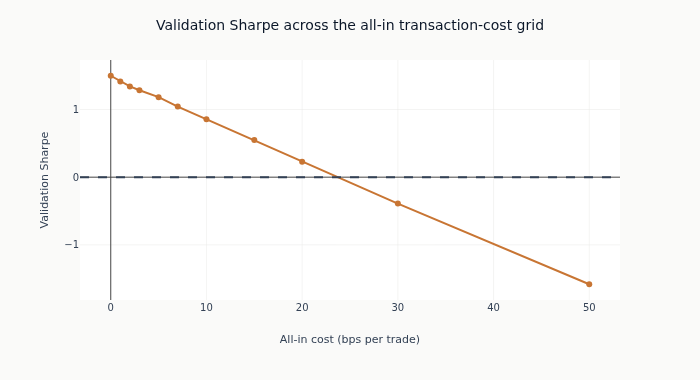

In [15]:
fig = px.line(
    cost_curve.to_pandas(),
    x="total_cost_bps",
    y="sharpe",
    markers=True,
    labels={"total_cost_bps": "All-in cost (bps per trade)", "sharpe": "Validation Sharpe"},
    color_discrete_sequence=[COLORS["copper"]],
)
fig.update_layout(
    title="Validation Sharpe across the all-in transaction-cost grid",
    height=380,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.show()

## The holdout

The holdout evaluates one configuration: the one the validation backtests selected. That is the
highest validation backtest Sharpe across the baseline, position-sizing, allocation and
risk-management stages, and it is fixed before any holdout artifact exists.

What keeps the holdout from becoming an axis to search over is the direction of that rule, not a
gate. The ranking reads validation rows only, and the holdout row below is found by matching the
selected strategy specification - never by taking whichever holdout backtest scored best. A
holdout number therefore cannot change which configuration is reported here.

Nothing about it is one-shot. A holdout result that turns out to be wrong is deleted and produced
again; what would make the number uninterpretable is evaluating many configurations on the window
and reporting the best, which is the thing the selection rule rules out. The holdout notebooks
produce the row; this one reads it. Where they have not run, the table is empty and the validation
result above stands on its own.

In [16]:
# `select_holdout_self_backtest` is the shared resolver every strategy-analysis notebook uses.
# It takes the selection this notebook already made and finds the holdout backtest replaying that
# same strategy specification, at the same configuration and checkpoint, over a training run whose
# own CV declares the holdout fold. It returns None where no such run exists, and raises rather
# than choosing where two of them do.
#
# Calling it rather than re-deriving the lineage here is deliberate. A second implementation
# living beside the first agrees with it on the registry it was written against and diverges on
# the next one, and a divergence in this particular lookup is a holdout number attributed to the
# wrong configuration.
holdout_backtest_hash = select_holdout_self_backtest("cme_futures", selected.hash)
print(
    f"Selected validation backtest: {selected.hash}  ({selected_label})\n"
    f"Holdout replay: {holdout_backtest_hash or 'not produced yet'}"
)

Selected validation backtest: 619a5cd773b4  (fwd_ret_5d)
Holdout replay: 583c7470539e


In [17]:
if holdout_backtest_hash is None:
    comparison = pl.DataFrame()
else:
    evaluated = study.backtests.table(include_preview=True).filter(
        pl.col("backtest_hash") == holdout_backtest_hash
    )
    comparison = pl.concat(
        [
            selected_row.select("label", "sharpe", "max_drawdown", "num_trades").with_columns(
                pl.lit("validation").alias("split")
            ),
            evaluated.select("label", "sharpe", "max_drawdown", "num_trades").with_columns(
                pl.lit("holdout").alias("split")
            ),
        ]
    ).select("split", "label", "sharpe", "max_drawdown", "num_trades")
comparison

split,label,sharpe,max_drawdown,num_trades
str,str,f64,f64,f64
"""validation""","""fwd_ret_5d""",1.235576,-0.258975,2355.0
"""holdout""","""fwd_ret_5d""",0.286844,-0.13283,970.0
